# Storm Kristin, Portugal — January 2026

Storm Kristin made landfall on the Iberian Peninsula in late January 2026, bringing significant precipitation to Portugal and Spain. This report summarizes station-level precipitation and temperature data from NOAA's [Global Historical Climatology Network – Daily (GHCN-D)](https://www.ncei.noaa.gov/pub/data/ghcn/daily/) for stations within a bounding box covering the Iberian Peninsula and surrounding region (35–45°N, 15°W–5°E).

**This notebook is self-contained.** All helper functions are inlined below — no `soa_weather` package installation is required. You only need:

- `polars`, `great-tables`, `cartopy`, `matplotlib`, `numpy`
- Data files on disk at `C:/Data/SOA_Weather` (station metadata CSV and `ghcnd_all/` directory of `.dly` files)

```
pip install polars great-tables cartopy matplotlib numpy
```

> **Note:** Cartopy can be tricky to install on Windows. If `pip install cartopy` fails, try `conda install -c conda-forge cartopy`.

## Data Sources and Format

**GHCN-Daily** is maintained by NOAA's National Centers for Environmental Information (NCEI). It contains daily climate summaries from ~120,000 land-based stations worldwide.

### Files used

| File | Description | Source |
|---|---|---|
| `stations_output.csv` | Pre-processed station metadata (ID, lat/lon, elevation, country) | Derived from NOAA's [`ghcnd-stations.txt`](https://www.ncei.noaa.gov/pub/data/ghcn/daily/ghcnd-stations.txt) |
| `ghcnd_all/*.dly` | One file per station containing daily observations across full history | From [`ghcnd_all.tar.gz`](https://www.ncei.noaa.gov/pub/data/ghcn/daily/ghcnd_all.tar.gz) (~4 GB compressed) |

### `.dly` fixed-width format

Each line encodes **one month** of daily values for a single element at one station:

| Columns | Field | Example |
|---|---|---|
| 1–11 | Station ID | `SPE00120354` |
| 12–15 | Year | `2026` |
| 16–17 | Month | `01` |
| 18–21 | Element code | `PRCP`, `TMAX`, `TMIN` |
| 22+ | 31 × 8-char groups: VALUE(5) MFLAG(1) QFLAG(1) SFLAG(1) | |

- **Missing values** are encoded as `-9999`
- **Quality flags** (`qflag`): blank = passed all QA checks; any other character = suspect/erroneous
- **Raw units**: temperatures in tenths of °C, precipitation in tenths of mm

In [1]:
import sys
import time
from datetime import date
from pathlib import Path
from typing import Literal

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from great_tables import GT, loc, style

In [2]:
# ---------------------------------------------------------------------------
# Inlined helper functions (from soa_weather package)
# These are copied verbatim from src/soa_weather/ so the notebook is
# self-contained and can be shared without installing the package.
# ---------------------------------------------------------------------------


# ── Unit conversion expressions (from utils.py) ────────────────────────────


def tenths_to_unit(expr: pl.Expr) -> pl.Expr:
    """Divide by 10 to convert NOAA tenths-of-unit storage to the base unit.

    NOAA stores TMAX, TMIN, TAVG as tenths of °C and PRCP as tenths of mm.
    """
    return expr / 10


def celsius_to_fahrenheit(expr: pl.Expr) -> pl.Expr:
    """Convert °C to °F."""
    return expr * 9 / 5 + 32


def mm_to_inches(expr: pl.Expr) -> pl.Expr:
    """Convert millimetres to inches."""
    return expr / 25.4


# ── .dly parsing (from read.py) ────────────────────────────────────────────


def parse_dly(dly_file: Path) -> pl.DataFrame:
    """Parse a single GHCN-Daily .dly file into a long-format DataFrame.

    Each line represents one month of observations for one element at one station.
    Fixed-width layout per line (1-based NOAA column numbers):

    - Cols  1-11: Station ID
    - Cols 12-15: Year
    - Cols 16-17: Month
    - Cols 18-21: Element (e.g. TMAX, TMIN, PRCP)
    - Then 31 groups of 8 chars (one per day): VALUE(5) MFLAG(1) QFLAG(1) SFLAG(1)

    Missing values (-9999) and invalid calendar dates (e.g. Feb 30) are dropped.
    """
    lines = [line for line in dly_file.read_text().splitlines() if len(line) >= 21]
    if not lines:
        return pl.DataFrame()

    raw = (
        pl.DataFrame({"line": lines})
        .with_columns(
            pl.col("line").str.slice(0, 11).str.strip_chars().alias("station_id"),
            pl.col("line").str.slice(11, 4).cast(pl.Int32).alias("year"),
            pl.col("line").str.slice(15, 2).cast(pl.Int32).alias("month"),
            pl.col("line").str.slice(17, 4).str.strip_chars().alias("element"),
            *[
                pl.struct(
                    pl.col("line")
                    .str.slice(21 + (d - 1) * 8, 5)
                    .str.strip_chars()
                    .cast(pl.Int64)
                    .alias("value"),
                    pl.col("line").str.slice(21 + (d - 1) * 8 + 5, 1).alias("mflag"),
                    pl.col("line").str.slice(21 + (d - 1) * 8 + 6, 1).alias("qflag"),
                    pl.col("line").str.slice(21 + (d - 1) * 8 + 7, 1).alias("sflag"),
                ).alias(str(d))
                for d in range(1, 32)
            ],
        )
        .drop("line")
    )

    return (
        raw.unpivot(
            on=[str(d) for d in range(1, 32)],
            index=["station_id", "year", "month", "element"],
            variable_name="day",
            value_name="obs",
        )
        .with_columns(
            pl.col("day").cast(pl.Int32),
            pl.col("obs").struct.field("value").alias("value"),
            pl.col("obs").struct.field("mflag").alias("mflag"),
            pl.col("obs").struct.field("qflag").alias("qflag"),
            pl.col("obs").struct.field("sflag").alias("sflag"),
        )
        .drop("obs")
        .filter(pl.col("value") != -9999)
        .with_columns(
            (
                pl.col("year").cast(pl.String).str.zfill(4)
                + pl.col("month").cast(pl.String).str.zfill(2)
                + pl.col("day").cast(pl.String).str.zfill(2)
            )
            .str.to_date(format="%Y%m%d", strict=False)
            .alias("date")
        )
        .filter(pl.col("date").is_not_null())
        .select("station_id", "date", "element", "value", "mflag", "qflag", "sflag")
        .sort("station_id", "date", "element")
    )


def load_station_observations(station_ids: list[str], dly_subdir: Path) -> pl.DataFrame:
    """Load and concatenate .dly observation files for a list of station IDs.

    Parameters
    ----------
    station_ids : list[str]
        GHCN station identifiers to load.
    dly_subdir : Path
        Directory containing .dly files (may be nested).
    """
    total = len(station_ids)
    print(f"Loading observations for {total:,} stations...")
    t0 = time.time()
    frames = []
    for i, sid in enumerate(station_ids, 1):
        dly_file = next(dly_subdir.rglob(f"{sid}.dly"), None)
        if dly_file is None:
            print(f"  WARNING: No .dly file found for station {sid}")
            continue
        frames.append(parse_dly(dly_file))
        if i % 10 == 0 or i == total:
            elapsed = time.time() - t0
            sys.stdout.write(f"\r  {i:,} / {total:,} stations ({elapsed:.0f}s)")
            sys.stdout.flush()
    sys.stdout.write("\n")
    if not frames:
        return pl.DataFrame()
    print(f"Concatenating {len(frames):,} station frames...")
    result = pl.concat(frames)
    print(f"Done — {result.height:,} observations loaded in {time.time() - t0:.1f}s")
    return result


def pivot_observations(
    obs: pl.DataFrame,
    element: str,
    date_start: date,
    date_end: date,
    completeness_threshold: float = 0.0,
) -> pl.DataFrame:
    """Pivot long-format observations to wide format with one column per date.

    Parameters
    ----------
    obs : pl.DataFrame
        Long-format observations.
    element : str
        The element to pivot (e.g. "TMAX", "PRCP").
    date_start, date_end : date
        Inclusive date range.
    completeness_threshold : float
        Minimum fraction of days with data (0.0–1.0). Stations below this are dropped.
    """
    total_days = (date_end - date_start).days + 1

    filtered = obs.filter(
        (pl.col("element") == element)
        & (pl.col("date") >= date_start)
        & (pl.col("date") <= date_end)
    ).select("station_id", "date", "value")

    completeness = filtered.group_by("station_id").agg(
        (pl.col("value").count() / total_days).alias("data_complete_pct")
    )

    if completeness_threshold > 0.0:
        passing = completeness.filter(pl.col("data_complete_pct") >= completeness_threshold)[
            "station_id"
        ]
        filtered = filtered.filter(pl.col("station_id").is_in(passing))
        completeness = completeness.filter(pl.col("station_id").is_in(passing))

    wide = filtered.pivot(values="value", index="station_id", on="date", aggregate_function="first")

    date_cols = sorted(c for c in wide.columns if c != "station_id")

    return (
        wide.join(completeness, on="station_id", how="left")
        .select(["station_id", "data_complete_pct", *date_cols])
        .sort("station_id")
    )


# ── Quality filtering and unit conversion (from clean.py) ──────────────────


def filter_ghcn_quality_flags(df: pl.DataFrame) -> pl.DataFrame:
    """Remove observations that failed NOAA quality assurance checks.

    Drops rows where qflag is not blank. A blank qflag means the observation
    passed all QA checks.
    """
    return df.filter(pl.col("qflag") == " ")


def clean_ghcn_daily_observations(
    df: pl.DataFrame,
    system: Literal["metric", "imperial"] = "metric",
) -> pl.DataFrame:
    """Convert raw NOAA integer observation values to standard units.

    NOAA stores values as integers in the following raw units:

    - TMAX, TMIN, TAVG: tenths of °C
    - PRCP:             tenths of mm
    - SNOW, SNWD:       mm (not tenths)
    - All other elements are passed through unchanged.

    Parameters
    ----------
    df : pl.DataFrame
        Long-format observations with ``element`` and ``value`` columns.
    system : {"metric", "imperial"}
        Target unit system.
    """
    temp_elements = ["TMAX", "TMIN", "TAVG"]
    prcp_elements = ["PRCP", "MDPR", "DAPR"]
    snow_elements = ["SNOW", "SNWD"]

    if system == "metric":
        converted = (
            pl.when(pl.col("element").is_in(temp_elements + prcp_elements))
            .then(tenths_to_unit(pl.col("value").cast(pl.Float64)))
            .otherwise(pl.col("value").cast(pl.Float64))
            .alias("value")
        )
    else:
        converted = (
            pl.when(pl.col("element").is_in(temp_elements))
            .then(celsius_to_fahrenheit(tenths_to_unit(pl.col("value").cast(pl.Float64))))
            .when(pl.col("element").is_in(prcp_elements))
            .then(mm_to_inches(tenths_to_unit(pl.col("value").cast(pl.Float64))))
            .when(pl.col("element").is_in(snow_elements))
            .then(mm_to_inches(pl.col("value").cast(pl.Float64)))
            .otherwise(pl.col("value").cast(pl.Float64))
            .alias("value")
        )

    return df.with_columns(converted)

In [3]:
# ── Configuration ─────────────────────────────────────────────────────────────
# Change DATA_DIR if your data lives elsewhere.

DATA_DIR = Path("C:/Data/SOA_Weather")
DLY_SUBDIR = DATA_DIR / "ghcnd_all"
area_dict = {"north": 45.0, "west": -15.0, "south": 35.0, "east": 5.0}
date_start = date(2026, 1, 25)
date_end = date(2026, 1, 31)
data_completeness_min = 0.0  # minimum fraction of days a station must report (0.0–1.0)

## Station Metadata

Station metadata is sourced from NOAA's `ghcnd-stations.txt`, pre-processed and stored locally as `stations_output.csv`. Stations are filtered to those with `.dly` observation files on disk and falling within the bounding box.

In [4]:
station_df = pl.read_csv(source=DATA_DIR / "stations_output.csv", infer_schema_length=1_000_000)

filtered_stations = station_df.filter(
    (pl.col("latitude") >= area_dict["south"])
    & (pl.col("latitude") <= area_dict["north"])
    & (pl.col("longitude") >= area_dict["west"])
    & (pl.col("longitude") <= area_dict["east"])
)
station_ids = filtered_stations["station_id"].to_list()
print(f"{len(station_ids):,} stations in bounding box")

275 stations in bounding box


In [5]:
(
    GT(filtered_stations.head(10))
    .tab_header(
        title="Station Metadata (first 10 rows)",
        subtitle=f"{len(station_ids):,} stations in bounding box",
    )
    .cols_label(
        country_code="Code",
        country_name="Country",
        state="State",
        station_id="Station ID",
        station_name="Station Name",
        latitude="Lat",
        longitude="Lon",
        elevation="Elev (m)",
    )
    .fmt_number(columns=["latitude", "longitude"], decimals=2)
    .tab_style(style=style.css("white-space: nowrap;"), locations=loc.column_labels())
)

GT(_tbl_data=shape: (10, 8)
┌─────────────┬─────────────┬───────┬─────────────┬─────────────┬──────────┬───────────┬───────────┐
│ country_cod ┆ country_nam ┆ state ┆ station_id  ┆ station_nam ┆ latitude ┆ longitude ┆ elevation │
│ e           ┆ e           ┆ ---   ┆ ---         ┆ e           ┆ ---      ┆ ---       ┆ ---       │
│ ---         ┆ ---         ┆ str   ┆ str         ┆ ---         ┆ f64      ┆ f64       ┆ i64       │
│ str         ┆ str         ┆       ┆             ┆ str         ┆          ┆           ┆           │
╞═════════════╪═════════════╪═══════╪═════════════╪═════════════╪══════════╪═══════════╪═══════════╡
│ AG          ┆ Algeria     ┆       ┆ AG000060390 ┆ ALGER-DAR   ┆ 36.72    ┆ 3.25      ┆ 24        │
│             ┆             ┆       ┆             ┆ EL BEIDA    ┆          ┆           ┆           │
│ AG          ┆ Algeria     ┆       ┆ AGE00135039 ┆ ORAN-HOPITA ┆ 35.73    ┆ 0.65      ┆ 50        │
│             ┆             ┆       ┆             ┆ L MILITAIRE ┆          ┆           ┆           │
│ AG          ┆ Algeria     ┆       ┆ AGE00147705 ┆ ALGIERS-VIL ┆ 36.78    ┆ 3.07      ┆ 59        │
│             ┆             ┆       ┆             ┆ LE/UNIVERSI ┆          ┆           ┆           │
│             ┆             ┆       ┆             ┆ TE          ┆          ┆           ┆           │
│ AG          ┆ Algeria     ┆       ┆ AGE00147706 ┆ ALGIERS-BOU ┆ 36.8     ┆ 3.03      ┆ 344       │
│             ┆             ┆       ┆             ┆ ZAREAH      ┆          ┆           ┆           │
│ AG          ┆ Algeria     ┆       ┆ AGE00147707 ┆ ALGIERS-CAP ┆ 36.8     ┆ 3.04      ┆ 38        │
│             ┆             ┆       ┆             ┆ CAXINE      ┆          ┆           ┆           │
│ AG          ┆ Algeria     ┆       ┆ AGE00147708 ┆ TIZI OUZOU  ┆ 36.72    ┆ 4.05      ┆ 222       │
│ AG          ┆ Algeria     ┆       ┆ AGE00147709 ┆ FORT        ┆ 36.63    ┆ 4.2       ┆ 942       │
│             ┆             ┆       ┆             ┆ NATIONAL    ┆          ┆           ┆           │
│ AG          ┆ Algeria     ┆       ┆ AGE00147712 ┆ ORLEANSVILL ┆ 36.17    ┆ 1.34      ┆ 112       │
│             ┆             ┆       ┆             ┆ E (CHLEF)   ┆          ┆           ┆           │
│ AG          ┆ Algeria     ┆       ┆ AGE00147714 ┆ ORAN-CAP    ┆ 35.77    ┆ 0.8       ┆ 78        │
│             ┆             ┆       ┆             ┆ FALCON      ┆          ┆           ┆           │
│ AG          ┆ Algeria     ┆       ┆ AGE00147716 ┆ NEMOURS     ┆ 35.1     ┆ -1.85     ┆ 83        │
│             ┆             ┆       ┆             ┆ (GHAZAOUET) ┆          ┆           ┆           │
└─────────────┴─────────────┴───────┴─────────────┴─────────────┴──────────┴───────────┴───────────┘, _body=<great_tables._gt_data.Body object at 0x0000023F71E2E810>, _boxhead=Boxhead([ColInfo(var='country_code', type=<ColInfoTypeEnum.default: 1>, column_label='Code', column_align='left', column_width=None), ColInfo(var='country_name', type=<ColInfoTypeEnum.default: 1>, column_label='Country', column_align='left', column_width=None), ColInfo(var='state', type=<ColInfoTypeEnum.default: 1>, column_label='State', column_align='left', column_width=None), ColInfo(var='station_id', type=<ColInfoTypeEnum.default: 1>, column_label='Station ID', column_align='left', column_width=None), ColInfo(var='station_name', type=<ColInfoTypeEnum.default: 1>, column_label='Station Name', column_align='left', column_width=None), ColInfo(var='latitude', type=<ColInfoTypeEnum.default: 1>, column_label='Lat', column_align='right', column_width=None), ColInfo(var='longitude', type=<ColInfoTypeEnum.default: 1>, column_label='Lon', column_align='right', column_width=None), ColInfo(var='elevation', type=<ColInfoTypeEnum.default: 1>, column_label='Elev (m)', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x0000023F71E65A30>, _spanners=Spanners([]), _heading=Heading(title='Station Metadata (first 10 rows)', subtitl

## Observations

Observations are loaded from GHCN-D `.dly` files — one file per station. Each file contains daily measurements for all recorded elements (precipitation, max/min temperature, snow depth, etc.) across the full station history. Quality-flagged records are removed and values are converted to metric units (precipitation in mm, temperature in °C).

> **Note:** The cell below loads `.dly` files for all stations in the bounding box. This may take several minutes depending on disk speed and station count.

In [6]:
obs = load_station_observations(station_ids, DLY_SUBDIR)

Loading observations for 275 stations...
  275 / 275 stations (43s)
Concatenating 275 station frames...
Done — 13,891,399 observations loaded in 42.7s


In [7]:
obs = filter_ghcn_quality_flags(obs)
obs = clean_ghcn_daily_observations(obs, system="metric")

In [8]:
(
    GT(
        obs.join(
            filtered_stations.select(["station_id", "station_name", "country_name"]),
            on="station_id",
            how="left",
        )
        .select(
            [
                "station_id",
                "station_name",
                "country_name",
                "date",
                "element",
                "value",
                "mflag",
                "qflag",
                "sflag",
            ]
        )
        .head(10)
    )
    .tab_header(
        title="Observations (first 10 rows)",
        subtitle="Long format — one row per station × date × element",
    )
    .cols_label(
        station_id="Station ID",
        station_name="Station",
        country_name="Country",
        date="Date",
        element="Element",
        value="Value",
        mflag="M Flag",
        qflag="Q Flag",
        sflag="S Flag",
    )
    .fmt_number(columns=["value"], decimals=1)
    .tab_style(style=style.css("white-space: nowrap;"), locations=loc.column_labels())
)

GT(_tbl_data=shape: (10, 9)
┌─────────────┬────────────────────┬──────────────┬────────────┬───┬───────┬───────┬───────┬───────┐
│ station_id  ┆ station_name       ┆ country_name ┆ date       ┆ … ┆ value ┆ mflag ┆ qflag ┆ sflag │
│ ---         ┆ ---                ┆ ---          ┆ ---        ┆   ┆ ---   ┆ ---   ┆ ---   ┆ ---   │
│ str         ┆ str                ┆ str          ┆ date       ┆   ┆ f64   ┆ str   ┆ str   ┆ str   │
╞═════════════╪════════════════════╪══════════════╪════════════╪═══╪═══════╪═══════╪═══════╪═══════╡
│ AG000060390 ┆ ALGER-DAR EL BEIDA ┆ Algeria      ┆ 1940-01-01 ┆ … ┆ 0.0   ┆       ┆       ┆ E     │
│ AG000060390 ┆ ALGER-DAR EL BEIDA ┆ Algeria      ┆ 1940-01-01 ┆ … ┆ 22.4  ┆       ┆       ┆ G     │
│ AG000060390 ┆ ALGER-DAR EL BEIDA ┆ Algeria      ┆ 1940-01-01 ┆ … ┆ 4.7   ┆       ┆       ┆ E     │
│ AG000060390 ┆ ALGER-DAR EL BEIDA ┆ Algeria      ┆ 1940-01-02 ┆ … ┆ 0.0   ┆       ┆       ┆ E     │
│ AG000060390 ┆ ALGER-DAR EL BEIDA ┆ Algeria      ┆ 1940-01-02 ┆ … ┆ 20.2  ┆       ┆       ┆ G     │
│ AG000060390 ┆ ALGER-DAR EL BEIDA ┆ Algeria      ┆ 1940-01-02 ┆ … ┆ 8.8   ┆       ┆       ┆ E     │
│ AG000060390 ┆ ALGER-DAR EL BEIDA ┆ Algeria      ┆ 1940-01-03 ┆ … ┆ 1.8   ┆       ┆       ┆ E     │
│ AG000060390 ┆ ALGER-DAR EL BEIDA ┆ Algeria      ┆ 1940-01-03 ┆ … ┆ 21.0  ┆       ┆       ┆ G     │
│ AG000060390 ┆ ALGER-DAR EL BEIDA ┆ Algeria      ┆ 1940-01-03 ┆ … ┆ 11.0  ┆       ┆       ┆ E     │
│ AG000060390 ┆ ALGER-DAR EL BEIDA ┆ Algeria      ┆ 1940-01-04 ┆ … ┆ 18.5  ┆       ┆       ┆ E     │
└─────────────┴────────────────────┴──────────────┴────────────┴───┴───────┴───────┴───────┴───────┘, _body=<great_tables._gt_data.Body object at 0x0000023F71EB7CE0>, _boxhead=Boxhead([ColInfo(var='station_id', type=<ColInfoTypeEnum.default: 1>, column_label='Station ID', column_align='left', column_width=None), ColInfo(var='station_name', type=<ColInfoTypeEnum.default: 1>, column_label='Station', column_align='left', column_width=None), ColInfo(var='country_name', type=<ColInfoTypeEnum.default: 1>, column_label='Country', column_align='left', column_width=None), ColInfo(var='date', type=<ColInfoTypeEnum.default: 1>, column_label='Date', column_align='right', column_width=None), ColInfo(var='element', type=<ColInfoTypeEnum.default: 1>, column_label='Element', column_align='left', column_width=None), ColInfo(var='value', type=<ColInfoTypeEnum.default: 1>, column_label='Value', column_align='right', column_width=None), ColInfo(var='mflag', type=<ColInfoTypeEnum.default: 1>, column_label='M Flag', column_align='left', column_width=None), ColInfo(var='qflag', type=<ColInfoTypeEnum.default: 1>, column_label='Q Flag', column_align='left', column_width=None), ColInfo(var='sflag', type=<ColInfoTypeEnum.default: 1>, column_label='S Flag', column_align='left', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x0000023F71EAD520>, _spanners=Spanners([]), _heading=Heading(title='Observations (first 10 rows)', subtitle='Long format — one row per station × date × element', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x0000023F71EB7E90>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x0000023F71EACE90>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='station_id', rownum=None, colnum=None, styles=[CellStyleCss(rule='white-space: nowrap;')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='station_name', rownum=None, colnum=None, styles=[CellStyleCss(rule='white-space: nowrap;')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='country_name', rownum=None, colnum=None, styles=[CellStyleCss(rule='white-space: nowrap;')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='date', rownum=None, colnum=None, styles=[CellStyleCss(rule='white-space: nowrap;')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None,

## Precipitation

Daily precipitation (PRCP) is pivoted to wide format: one row per station, one column per calendar date. Only stations reporting on the minimum completeness threshold are retained.

In [9]:
prcp_wide = pivot_observations(
    obs,
    element="PRCP",
    date_start=date_start,
    date_end=date_end,
    completeness_threshold=data_completeness_min,
)

In [10]:
_prcp_date_cols = [c for c in prcp_wide.columns if c not in ["station_id", "data_complete_pct"]]
(
    GT(
        prcp_wide.join(
            filtered_stations.select(["station_id", "station_name", "country_name"]),
            on="station_id",
            how="left",
        )
        .select(
            ["station_id", "station_name", "country_name", "data_complete_pct", *_prcp_date_cols]
        )
        .head(10)
    )
    .tab_header(
        title="Precipitation — Wide Format (first 10 rows)",
        subtitle=(
            f"Values in mm; minimum completeness threshold: {int(data_completeness_min * 100)}%"
        ),
    )
    .cols_label(
        station_id="Station ID",
        station_name="Station",
        country_name="Country",
        data_complete_pct="Completeness",
    )
    .fmt_percent(columns=["data_complete_pct"], decimals=0)
    .fmt_number(columns=_prcp_date_cols, decimals=1)
    .tab_style(style=style.css("white-space: nowrap;"), locations=loc.column_labels())
)

GT(_tbl_data=shape: (10, 11)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ station_i ┆ station_n ┆ country_n ┆ data_comp ┆ … ┆ 2026-01-2 ┆ 2026-01-2 ┆ 2026-01-3 ┆ 2026-01- │
│ d         ┆ ame       ┆ ame       ┆ lete_pct  ┆   ┆ 8         ┆ 9         ┆ 0         ┆ 31       │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│ str       ┆ str       ┆ str       ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ FR0000075 ┆ BORDEAUX- ┆ France    ┆ 1.0       ┆ … ┆ 1.8       ┆ 5.2       ┆ 8.3       ┆ 13.8     │
│ 10        ┆ MERIGNAC  ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│ FR0000076 ┆ TOULOUSE- ┆ France    ┆ 1.0       ┆ … ┆ 0.2       ┆ 5.2       ┆ 6.2       ┆ 3.4      │
│ 30        ┆ BLAGNAC   ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│ FR0000077 ┆ PERPIGNAN ┆ France    ┆ 1.0       ┆ … ┆ 0.0       ┆ 1.4       ┆ 2.0       ┆ 0.0      │
│ 47        ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│ FRE001041 ┆ TARBES -  ┆ France    ┆ 1.0       ┆ … ┆ 0.0       ┆ 9.5       ┆ 13.9      ┆ 24.1     │
│ 16        ┆ OSSUN     ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│ FRE001049 ┆ MONTELIMA ┆ France    ┆ 1.0       ┆ … ┆ 0.6       ┆ 0.0       ┆ 0.0       ┆ 0.2      │
│ 07        ┆ R         ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│ FRE001062 ┆ MILLAU    ┆ France    ┆ 1.0       ┆ … ┆ 0.0       ┆ 7.8       ┆ 5.0       ┆ 2.2      │
│ 00        ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│ FRE001062 ┆ MONT-DE-M ┆ France    ┆ 1.0       ┆ … ┆ 5.0       ┆ 14.2      ┆ 13.9      ┆ 11.8     │
│ 03        ┆ ARSAN     ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│ FRE001062 ┆ ST-GIRONS ┆ France    ┆ 1.0       ┆ … ┆ 0.0       ┆ 5.6       ┆ 6.4       ┆ 14.2     │
│ 05        ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│ FRE001062 ┆ MONTPELLI ┆ France    ┆ 1.0       ┆ … ┆ 0.6       ┆ 0.0       ┆ 0.6       ┆ 2.6      │
│ 07        ┆ ER-AEROPO ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ RT        ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│ FRM000075 ┆ GOURDON   ┆ France    ┆ 1.0       ┆ … ┆ 0.0       ┆ 9.0       ┆ 4.4       ┆ 1.8      │
│ 35        ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
└───────────┴───────────┴───────────┴───────────┴───┴───────────┴───────────┴───────────┴──────────┘, _body=<great_tables._gt_data.Body object at 0x0000023F71EB7020>, _boxhead=Boxhead([ColInfo(var='station_id', type=<ColInfoTypeEnum.default: 1>, column_label='Station ID', column_align='left', column_width=None), ColInfo(var='station_name', type=<ColInfoTypeEnum.default: 1>, column_label='Station', column_align='left', column_width=None), ColInfo(var='country_name', type=<ColInfoTypeEnum.default: 1>, column_label='Country', column_align='left', column_width=None), ColInfo(var='data_complete_pct', type=<ColInfoTypeEnum.default: 1>, column_label='Completeness', column_align='right', column_width=None), ColInfo(var='2026-01-25', type=<ColInfoTypeEnum.default: 1>, column_label='2026-01-25', column_align='right', column_width=None), ColInfo(var='2026-01-26', type=<ColInfoTypeEnum.default: 1>, column_label='2026-01-26', column_align='right', column_width=None), ColInfo(var='2026-01-27', type=<ColInfoTypeEnum.default: 1>, column_label='2026-01-27', column_align='right', column_width=None), ColInfo(var='2026-01-28', type=<ColInfoTypeEnum.default: 1>, column_label='2026-01-28', column_align='right', column_width=None), ColInfo(var='20

## Temperature

Max temperature (TMAX) is pivoted using the same approach, with the same completeness threshold.

In [11]:
tmax_wide = pivot_observations(
    obs,
    element="TMAX",
    date_start=date_start,
    date_end=date_end,
    completeness_threshold=data_completeness_min,
)

In [12]:
_tmax_date_cols = [c for c in tmax_wide.columns if c not in ["station_id", "data_complete_pct"]]
(
    GT(
        tmax_wide.join(
            filtered_stations.select(["station_id", "station_name", "country_name"]),
            on="station_id",
            how="left",
        )
        .select(
            ["station_id", "station_name", "country_name", "data_complete_pct", *_tmax_date_cols]
        )
        .head(10)
    )
    .tab_header(
        title="Max Temperature — Wide Format (first 10 rows)",
        subtitle=(
            f"Values in °C; minimum completeness threshold: {int(data_completeness_min * 100)}%"
        ),
    )
    .cols_label(
        station_id="Station ID",
        station_name="Station",
        country_name="Country",
        data_complete_pct="Completeness",
    )
    .fmt_percent(columns=["data_complete_pct"], decimals=0)
    .fmt_number(columns=_tmax_date_cols, decimals=0)
    .tab_style(style=style.css("white-space: nowrap;"), locations=loc.column_labels())
)

GT(_tbl_data=shape: (10, 11)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ station_i ┆ station_n ┆ country_n ┆ data_comp ┆ … ┆ 2026-01-2 ┆ 2026-01-2 ┆ 2026-01-3 ┆ 2026-01- │
│ d         ┆ ame       ┆ ame       ┆ lete_pct  ┆   ┆ 8         ┆ 9         ┆ 0         ┆ 31       │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│ str       ┆ str       ┆ str       ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ AGM000604 ┆ ARZEW     ┆ Algeria   ┆ 0.857143  ┆ … ┆ 21.4      ┆ 21.0      ┆ 18.9      ┆ null     │
│ 52        ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│ FR0000075 ┆ BORDEAUX- ┆ France    ┆ 1.0       ┆ … ┆ 11.6      ┆ 12.8      ┆ 14.0      ┆ 13.3     │
│ 10        ┆ MERIGNAC  ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│ FR0000076 ┆ TOULOUSE- ┆ France    ┆ 1.0       ┆ … ┆ 10.4      ┆ 11.4      ┆ 15.9      ┆ 10.6     │
│ 30        ┆ BLAGNAC   ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│ FR0000077 ┆ PERPIGNAN ┆ France    ┆ 1.0       ┆ … ┆ 13.8      ┆ 14.5      ┆ 18.4      ┆ 13.9     │
│ 47        ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│ FRE001041 ┆ TARBES -  ┆ France    ┆ 1.0       ┆ … ┆ 9.8       ┆ 14.3      ┆ 16.0      ┆ 9.4      │
│ 16        ┆ OSSUN     ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│ FRE001049 ┆ MONTELIMA ┆ France    ┆ 1.0       ┆ … ┆ 8.7       ┆ 11.0      ┆ 14.8      ┆ 11.6     │
│ 07        ┆ R         ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│ FRE001062 ┆ MILLAU    ┆ France    ┆ 1.0       ┆ … ┆ 7.0       ┆ 8.2       ┆ 9.4       ┆ 7.4      │
│ 00        ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│ FRE001062 ┆ MONT-DE-M ┆ France    ┆ 1.0       ┆ … ┆ 12.4      ┆ 14.7      ┆ 16.5      ┆ 12.6     │
│ 03        ┆ ARSAN     ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│ FRE001062 ┆ ST-GIRONS ┆ France    ┆ 1.0       ┆ … ┆ 10.8      ┆ 12.0      ┆ 16.4      ┆ 9.8      │
│ 05        ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│ FRE001062 ┆ MONTPELLI ┆ France    ┆ 1.0       ┆ … ┆ 14.4      ┆ 12.9      ┆ 16.2      ┆ 14.7     │
│ 07        ┆ ER-AEROPO ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ RT        ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
└───────────┴───────────┴───────────┴───────────┴───┴───────────┴───────────┴───────────┴──────────┘, _body=<great_tables._gt_data.Body object at 0x0000023F71F908F0>, _boxhead=Boxhead([ColInfo(var='station_id', type=<ColInfoTypeEnum.default: 1>, column_label='Station ID', column_align='left', column_width=None), ColInfo(var='station_name', type=<ColInfoTypeEnum.default: 1>, column_label='Station', column_align='left', column_width=None), ColInfo(var='country_name', type=<ColInfoTypeEnum.default: 1>, column_label='Country', column_align='left', column_width=None), ColInfo(var='data_complete_pct', type=<ColInfoTypeEnum.default: 1>, column_label='Completeness', column_align='right', column_width=None), ColInfo(var='2026-01-25', type=<ColInfoTypeEnum.default: 1>, column_label='2026-01-25', column_align='right', column_width=None), ColInfo(var='2026-01-26', type=<ColInfoTypeEnum.default: 1>, column_label='2026-01-26', column_align='right', column_width=None), ColInfo(var='2026-01-27', type=<ColInfoTypeEnum.default: 1>, column_label='2026-01-27', column_align='right', column_width=None), ColInfo(var='2026-01-28', type=<ColInfoTypeEnum.default: 1>, column_label='2026-01-28', column_align='right', column_width=None), ColInfo(var='20

## Data Preparation

Precipitation totals are summed across the analysis window and joined with station coordinates and country metadata for mapping and analysis.

In [13]:
date_cols = [c for c in prcp_wide.columns if c not in ["station_id", "data_complete_pct"]]

prcp_map = (
    prcp_wide.with_columns(pl.sum_horizontal([pl.col(c) for c in date_cols]).alias("total_prcp"))
    .select(["station_id", "total_prcp", *date_cols])
    .join(
        filtered_stations.select(
            ["station_id", "latitude", "longitude", "station_name", "country_code", "country_name"]
        ),
        on="station_id",
    )
    .filter(pl.col("total_prcp").is_not_null())
)

In [14]:
(
    GT(
        prcp_map.select(
            ["station_id", "station_name", "country_name", "total_prcp", *date_cols]
        ).head(10)
    )
    .tab_header(
        title="Precipitation Map Data (first 10 rows)",
        subtitle=(
            f"Total and daily precipitation (mm), "
            f"{date_start.strftime('%b %d')}–"
            f"{date_end.strftime('%b %d, %Y')}"
        ),
    )
    .cols_label(
        station_id="Station ID",
        station_name="Station",
        country_name="Country",
        total_prcp="Total (mm)",
    )
    .fmt_number(columns=["total_prcp", *date_cols], decimals=1)
    .tab_style(style=style.css("white-space: nowrap;"), locations=loc.column_labels())
)

GT(_tbl_data=shape: (10, 11)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ station_i ┆ station_n ┆ country_n ┆ total_prc ┆ … ┆ 2026-01-2 ┆ 2026-01-2 ┆ 2026-01-3 ┆ 2026-01- │
│ d         ┆ ame       ┆ ame       ┆ p         ┆   ┆ 8         ┆ 9         ┆ 0         ┆ 31       │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│ str       ┆ str       ┆ str       ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ FR0000075 ┆ BORDEAUX- ┆ France    ┆ 70.9      ┆ … ┆ 1.8       ┆ 5.2       ┆ 8.3       ┆ 13.8     │
│ 10        ┆ MERIGNAC  ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│ FR0000076 ┆ TOULOUSE- ┆ France    ┆ 29.6      ┆ … ┆ 0.2       ┆ 5.2       ┆ 6.2       ┆ 3.4      │
│ 30        ┆ BLAGNAC   ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│ FR0000077 ┆ PERPIGNAN ┆ France    ┆ 9.8       ┆ … ┆ 0.0       ┆ 1.4       ┆ 2.0       ┆ 0.0      │
│ 47        ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│ FRE001041 ┆ TARBES -  ┆ France    ┆ 86.5      ┆ … ┆ 0.0       ┆ 9.5       ┆ 13.9      ┆ 24.1     │
│ 16        ┆ OSSUN     ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│ FRE001049 ┆ MONTELIMA ┆ France    ┆ 43.6      ┆ … ┆ 0.6       ┆ 0.0       ┆ 0.0       ┆ 0.2      │
│ 07        ┆ R         ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│ FRE001062 ┆ MILLAU    ┆ France    ┆ 29.7      ┆ … ┆ 0.0       ┆ 7.8       ┆ 5.0       ┆ 2.2      │
│ 00        ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│ FRE001062 ┆ MONT-DE-M ┆ France    ┆ 88.4      ┆ … ┆ 5.0       ┆ 14.2      ┆ 13.9      ┆ 11.8     │
│ 03        ┆ ARSAN     ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│ FRE001062 ┆ ST-GIRONS ┆ France    ┆ 58.8      ┆ … ┆ 0.0       ┆ 5.6       ┆ 6.4       ┆ 14.2     │
│ 05        ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│ FRE001062 ┆ MONTPELLI ┆ France    ┆ 17.5      ┆ … ┆ 0.6       ┆ 0.0       ┆ 0.6       ┆ 2.6      │
│ 07        ┆ ER-AEROPO ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ RT        ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│ FRM000075 ┆ GOURDON   ┆ France    ┆ 24.8      ┆ … ┆ 0.0       ┆ 9.0       ┆ 4.4       ┆ 1.8      │
│ 35        ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
└───────────┴───────────┴───────────┴───────────┴───┴───────────┴───────────┴───────────┴──────────┘, _body=<great_tables._gt_data.Body object at 0x0000023F71EAC680>, _boxhead=Boxhead([ColInfo(var='station_id', type=<ColInfoTypeEnum.default: 1>, column_label='Station ID', column_align='left', column_width=None), ColInfo(var='station_name', type=<ColInfoTypeEnum.default: 1>, column_label='Station', column_align='left', column_width=None), ColInfo(var='country_name', type=<ColInfoTypeEnum.default: 1>, column_label='Country', column_align='left', column_width=None), ColInfo(var='total_prcp', type=<ColInfoTypeEnum.default: 1>, column_label='Total (mm)', column_align='right', column_width=None), ColInfo(var='2026-01-25', type=<ColInfoTypeEnum.default: 1>, column_label='2026-01-25', column_align='right', column_width=None), ColInfo(var='2026-01-26', type=<ColInfoTypeEnum.default: 1>, column_label='2026-01-26', column_align='right', column_width=None), ColInfo(var='2026-01-27', type=<ColInfoTypeEnum.default: 1>, column_label='2026-01-27', column_align='right', column_width=None), ColInfo(var='2026-01-28', type=<ColInfoTypeEnum.default: 1>, column_label='2026-01-28', column_align='right', column_width=None), ColInfo(var='2026-01-29'

## Summary Statistics

In [15]:
stations_by_country = (
    filtered_stations.group_by("country_name", "country_code")
    .agg(pl.len().alias("station_count"))
    .sort("station_count", descending=True)
)
(
    GT(stations_by_country)
    .tab_header(title="Stations in Bounding Box by Country")
    .cols_label(country_name="Country", country_code="Code", station_count="Stations")
    .tab_style(style=style.css("white-space: nowrap;"), locations=loc.column_labels())
)

GT(_tbl_data=shape: (6, 3)
┌────────────────────────────┬──────────────┬───────────────┐
│ country_name               ┆ country_code ┆ station_count │
│ ---                        ┆ ---          ┆ ---           │
│ str                        ┆ str          ┆ u32           │
╞════════════════════════════╪══════════════╪═══════════════╡
│ Spain                      ┆ SP           ┆ 198           │
│ Algeria                    ┆ AG           ┆ 33            │
│ France                     ┆ FR           ┆ 20            │
│ Portugal                   ┆ PO           ┆ 18            │
│ Morocco                    ┆ MO           ┆ 5             │
│ Gibraltar [United Kingdom] ┆ GI           ┆ 1             │
└────────────────────────────┴──────────────┴───────────────┘, _body=<great_tables._gt_data.Body object at 0x0000023F71E67140>, _boxhead=Boxhead([ColInfo(var='country_name', type=<ColInfoTypeEnum.default: 1>, column_label='Country', column_align='left', column_width=None), ColInfo(var='country_code', type=<ColInfoTypeEnum.default: 1>, column_label='Code', column_align='left', column_width=None), ColInfo(var='station_count', type=<ColInfoTypeEnum.default: 1>, column_label='Stations', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x0000023F71F92990>, _spanners=Spanners([]), _heading=Heading(title='Stations in Bounding Box by Country', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x0000023F71F51310>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x0000023F71F51280>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='country_name', rownum=None, colnum=None, styles=[CellStyleCss(rule='white-space: nowrap;')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='country_code', rownum=None, colnum=None, styles=[CellStyleCss(rule='white-space: nowrap;')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='station_count', rownum=None, colnum=None, styles=[CellStyleCss(rule='white-space: nowrap;')])], _locale=<great_tables._gt_data.Locale object at 0x0000023F71F50710>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', typ

In [16]:
country_prcp = (
    prcp_map.group_by("country_name", "country_code")
    .agg(
        pl.len().alias("reporting_stations"),
        pl.col("total_prcp").median().round(1).alias("median_total_mm"),
        pl.col("total_prcp").min().round(1).alias("min_total_mm"),
        pl.col("total_prcp").max().round(1).alias("max_total_mm"),
    )
    .sort("median_total_mm", descending=True)
)
(
    GT(country_prcp)
    .tab_header(
        title="Total Precipitation by Country",
        subtitle=f"{date_start.strftime('%b %d')}–{date_end.strftime('%b %d, %Y')}",
    )
    .cols_label(
        country_name="Country",
        country_code="Code",
        reporting_stations="Stations",
        median_total_mm="Median (mm)",
        min_total_mm="Min (mm)",
        max_total_mm="Max (mm)",
    )
    .fmt_number(columns=["median_total_mm", "min_total_mm", "max_total_mm"], decimals=1)
    .tab_style(style=style.css("white-space: nowrap;"), locations=loc.column_labels())
)

GT(_tbl_data=shape: (2, 6)
┌──────────────┬──────────────┬────────────────────┬─────────────────┬──────────────┬──────────────┐
│ country_name ┆ country_code ┆ reporting_stations ┆ median_total_mm ┆ min_total_mm ┆ max_total_mm │
│ ---          ┆ ---          ┆ ---                ┆ ---             ┆ ---          ┆ ---          │
│ str          ┆ str          ┆ u32                ┆ f64             ┆ f64          ┆ f64          │
╞══════════════╪══════════════╪════════════════════╪═════════════════╪══════════════╪══════════════╡
│ Spain        ┆ SP           ┆ 75                 ┆ 43.7            ┆ 2.5          ┆ 184.8        │
│ France       ┆ FR           ┆ 10                 ┆ 36.7            ┆ 9.8          ┆ 88.4         │
└──────────────┴──────────────┴────────────────────┴─────────────────┴──────────────┴──────────────┘, _body=<great_tables._gt_data.Body object at 0x0000023F558C9DC0>, _boxhead=Boxhead([ColInfo(var='country_name', type=<ColInfoTypeEnum.default: 1>, column_label='Country', column_align='left', column_width=None), ColInfo(var='country_code', type=<ColInfoTypeEnum.default: 1>, column_label='Code', column_align='left', column_width=None), ColInfo(var='reporting_stations', type=<ColInfoTypeEnum.default: 1>, column_label='Stations', column_align='right', column_width=None), ColInfo(var='median_total_mm', type=<ColInfoTypeEnum.default: 1>, column_label='Median (mm)', column_align='right', column_width=None), ColInfo(var='min_total_mm', type=<ColInfoTypeEnum.default: 1>, column_label='Min (mm)', column_align='right', column_width=None), ColInfo(var='max_total_mm', type=<ColInfoTypeEnum.default: 1>, column_label='Max (mm)', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x0000023F71F90560>, _spanners=Spanners([]), _heading=Heading(title='Total Precipitation by Country', subtitle='Jan 25–Jan 31, 2026', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x0000023F71F51A90>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x0000023F71F519A0>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='country_name', rownum=None, colnum=None, styles=[CellStyleCss(rule='white-space: nowrap;')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='country_code', rownum=None, colnum=None, styles=[CellStyleCss(rule='white-space: nowrap;')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='reporting_stations', rownum=None, colnum=None, styles=[CellStyleCss(rule='white-space: nowrap;')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='median_total_mm', rownum=None, colnum=None, styles=[CellStyleCss(rule='white-space: nowrap;')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='min_total_mm', rownum=None, colnum=None, styles=[CellStyleCss(rule='white-space: nowrap;')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='max_total_mm', rownum=None, colnum=None, styles=[CellStyleCss(rule='white-space: nowrap;')])], _locale=<great_tables._gt_data.Locale object at 0x0000023F71F51C40>, _formats=[<great_tables._gt_data.FormatInfo object at 0x0000023F71F51D60>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', valu

In [17]:
daily_stats = pl.DataFrame(
    {
        "date": date_cols,
        "mean_mm": [round(prcp_map[c].mean() or 0.0, 1) for c in date_cols],
        "median_mm": [round(prcp_map[c].median() or 0.0, 1) for c in date_cols],
        "max_mm": [round(prcp_map[c].max() or 0.0, 1) for c in date_cols],
    }
)
(
    GT(daily_stats)
    .tab_header(title="Daily Precipitation Statistics — All Reporting Stations")
    .cols_label(date="Date", mean_mm="Mean (mm)", median_mm="Median (mm)", max_mm="Max (mm)")
    .fmt_number(columns=["mean_mm", "median_mm", "max_mm"], decimals=1)
    .tab_style(style=style.css("white-space: nowrap;"), locations=loc.column_labels())
)

GT(_tbl_data=shape: (7, 4)
┌────────────┬─────────┬───────────┬────────┐
│ date       ┆ mean_mm ┆ median_mm ┆ max_mm │
│ ---        ┆ ---     ┆ ---       ┆ ---    │
│ str        ┆ f64     ┆ f64       ┆ f64    │
╞════════════╪═════════╪═══════════╪════════╡
│ 2026-01-25 ┆ 5.1     ┆ 2.0       ┆ 30.8   │
│ 2026-01-26 ┆ 9.5     ┆ 4.4       ┆ 92.2   │
│ 2026-01-27 ┆ 10.8    ┆ 6.7       ┆ 67.8   │
│ 2026-01-28 ┆ 9.3     ┆ 7.7       ┆ 53.6   │
│ 2026-01-29 ┆ 5.0     ┆ 5.0       ┆ 26.0   │
│ 2026-01-30 ┆ 5.5     ┆ 4.1       ┆ 26.0   │
│ 2026-01-31 ┆ 1.8     ┆ 0.2       ┆ 24.1   │
└────────────┴─────────┴───────────┴────────┘, _body=<great_tables._gt_data.Body object at 0x0000023F70AB9310>, _boxhead=Boxhead([ColInfo(var='date', type=<ColInfoTypeEnum.default: 1>, column_label='Date', column_align='left', column_width=None), ColInfo(var='mean_mm', type=<ColInfoTypeEnum.default: 1>, column_label='Mean (mm)', column_align='right', column_width=None), ColInfo(var='median_mm', type=<ColInfoTypeEnum.default: 1>, column_label='Median (mm)', column_align='right', column_width=None), ColInfo(var='max_mm', type=<ColInfoTypeEnum.default: 1>, column_label='Max (mm)', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x0000023F71EAC7D0>, _spanners=Spanners([]), _heading=Heading(title='Daily Precipitation Statistics — All Reporting Stations', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x0000023F71EB4C50>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x0000023F71F52780>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='date', rownum=None, colnum=None, styles=[CellStyleCss(rule='white-space: nowrap;')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='mean_mm', rownum=None, colnum=None, styles=[CellStyleCss(rule='white-space: nowrap;')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='median_mm', rownum=None, colnum=None, styles=[CellStyleCss(rule='white-space: nowrap;')]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='max_mm', rownum=None, colnum=None, styles=[CellStyleCss(rule='white-space: nowrap;')])], _locale=<great_tables._gt_data.Locale object at 0x0000023F71F522A0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x0000023F71F521E0>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='t

In [18]:
import pathlib

output_dir = pathlib.Path("data")
output_dir.mkdir(parents=True, exist_ok=True)
export_path = output_dir / f"storm_kristin_prcp_{date_start}_{date_end}.csv"
prcp_map.write_csv(export_path)
print(f"Exported to {export_path}")

Exported to data\storm_kristin_prcp_2026-01-25_2026-01-31.csv


## Visualizations

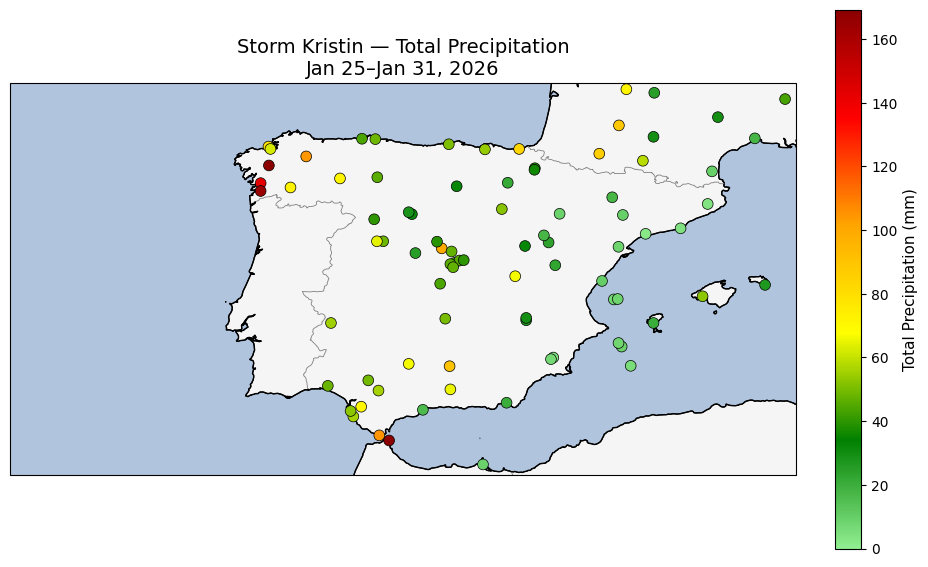

In [19]:
colors = ["lightgreen", "green", "yellow", "orange", "red", "darkred"]
cmap = mcolors.LinearSegmentedColormap.from_list("precip_cmap", colors)

lons = prcp_map["longitude"].to_numpy()
lats = prcp_map["latitude"].to_numpy()
totals = prcp_map["total_prcp"].to_numpy()
vmax = float(np.nanpercentile(totals, 98))

proj = ccrs.PlateCarree()
fig, ax = plt.subplots(1, 1, figsize=(10, 8), subplot_kw={"projection": proj})

scatter = ax.scatter(
    lons,
    lats,
    c=totals,
    cmap=cmap,
    vmin=0,
    vmax=vmax,
    s=60,
    edgecolors="black",
    linewidths=0.5,
    transform=ccrs.PlateCarree(),
    zorder=5,
)

ax.add_feature(cfeature.OCEAN, facecolor="lightsteelblue", zorder=0)
ax.add_feature(cfeature.LAND, facecolor="whitesmoke", edgecolor="black", zorder=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=2)
ax.add_feature(cfeature.BORDERS, linewidth=0.6, edgecolor="gray", zorder=2)
ax.set_extent([-15, 5, 35, 45], ccrs.PlateCarree())

cbar = plt.colorbar(scatter, ax=ax, shrink=0.7, pad=0.04)
cbar.set_label("Total Precipitation (mm)", fontsize=11)
ax.set_title(
    f"Storm Kristin — Total Precipitation\n"
    f"{date_start.strftime('%b %d')}–{date_end.strftime('%b %d, %Y')}",
    fontsize=14,
)
plt.tight_layout()
plt.show()

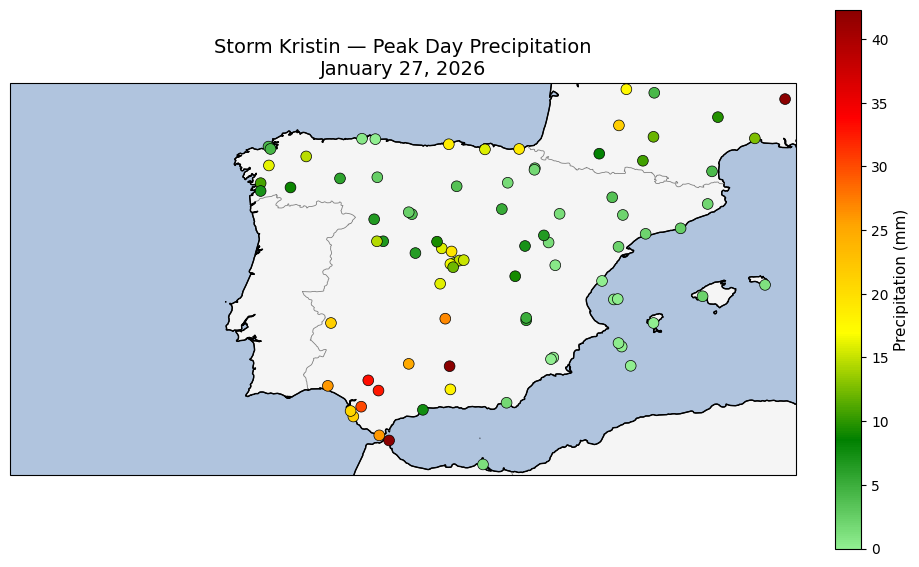

In [20]:
daily_means = {c: (prcp_map[c].mean() or 0.0) for c in date_cols}
peak_col = max(daily_means, key=daily_means.get)
peak_date = date.fromisoformat(peak_col)

peak_data = prcp_map.filter(pl.col(peak_col).is_not_null())
lons_pk = peak_data["longitude"].to_numpy()
lats_pk = peak_data["latitude"].to_numpy()
vals_pk = peak_data[peak_col].to_numpy()
vmax_pk = float(np.nanpercentile(vals_pk, 98))

fig, ax = plt.subplots(1, 1, figsize=(10, 8), subplot_kw={"projection": proj})

scatter_pk = ax.scatter(
    lons_pk,
    lats_pk,
    c=vals_pk,
    cmap=cmap,
    vmin=0,
    vmax=vmax_pk,
    s=60,
    edgecolors="black",
    linewidths=0.5,
    transform=ccrs.PlateCarree(),
    zorder=5,
)

ax.add_feature(cfeature.OCEAN, facecolor="lightsteelblue", zorder=0)
ax.add_feature(cfeature.LAND, facecolor="whitesmoke", edgecolor="black", zorder=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=2)
ax.add_feature(cfeature.BORDERS, linewidth=0.6, edgecolor="gray", zorder=2)
ax.set_extent([-15, 5, 35, 45], ccrs.PlateCarree())

cbar_pk = plt.colorbar(scatter_pk, ax=ax, shrink=0.7, pad=0.04)
cbar_pk.set_label("Precipitation (mm)", fontsize=11)
ax.set_title(
    f"Storm Kristin — Peak Day Precipitation\n{peak_date.strftime('%B %d, %Y')}",
    fontsize=14,
)
plt.tight_layout()
plt.show()

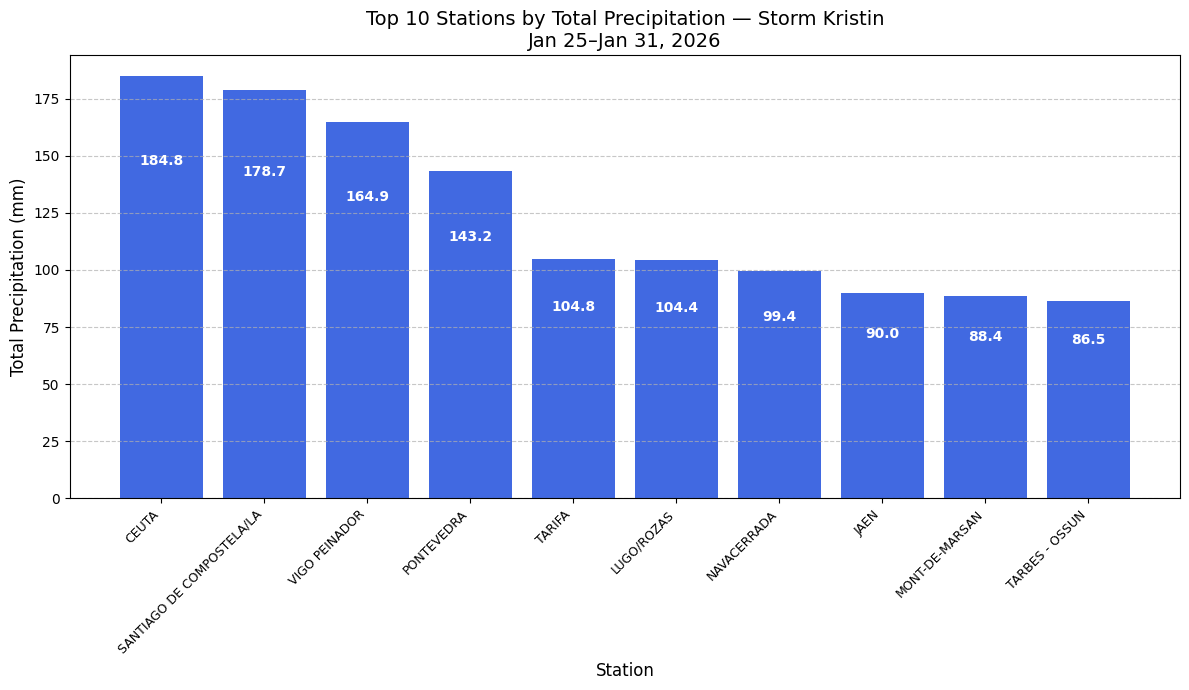

In [21]:
num_top = 10
top_stations = (
    prcp_map.sort("total_prcp", descending=True)
    .head(num_top)
    .with_columns(pl.col("station_name").str.slice(0, 25).alias("label"))
    .to_pandas()
)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.bar(top_stations["label"], top_stations["total_prcp"], color="royalblue")

for bar in bars:
    yval = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        yval * 0.8,
        f"{yval:.1f}",
        ha="center",
        va="center",
        color="white",
        fontsize=10,
        fontweight="bold",
    )

ax.set_xlabel("Station", fontsize=12)
ax.set_ylabel("Total Precipitation (mm)", fontsize=12)
ax.set_title(
    f"Top {num_top} Stations by Total Precipitation — Storm Kristin\n"
    f"{date_start.strftime('%b %d')}–{date_end.strftime('%b %d, %Y')}",
    fontsize=14,
)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

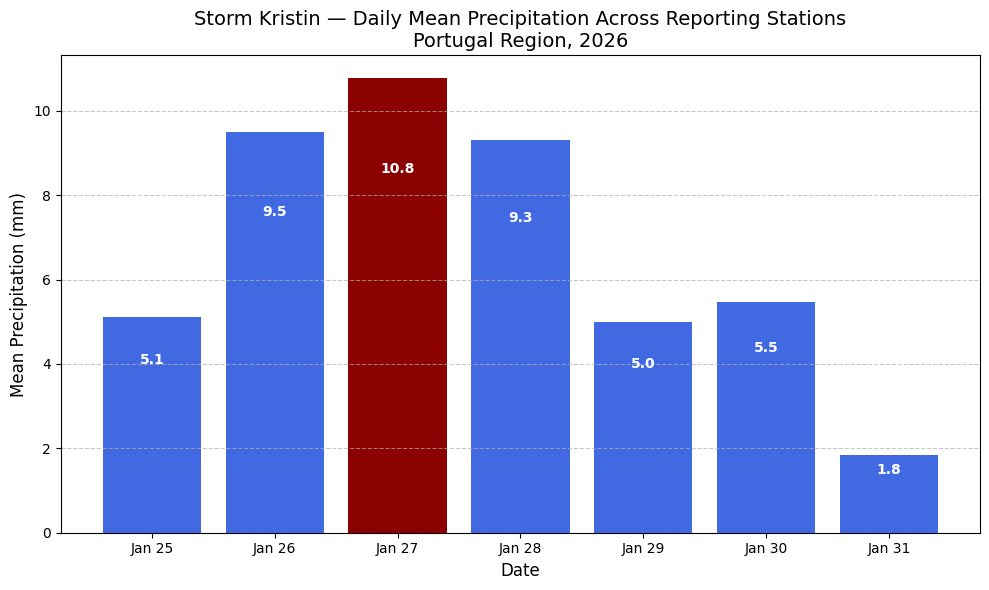

In [22]:
daily_vals = [(c, prcp_map[c].mean() or 0.0) for c in date_cols]
day_labels = [date.fromisoformat(c).strftime("%b %d") for c, _ in daily_vals]
day_means = [v for _, v in daily_vals]

peak_idx = int(np.argmax(day_means))
bar_colors = ["royalblue"] * len(day_labels)
bar_colors[peak_idx] = "darkred"

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(day_labels, day_means, color=bar_colors)

for bar in bars:
    yval = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        yval * 0.8,
        f"{yval:.1f}",
        ha="center",
        va="center",
        color="white",
        fontsize=10,
        fontweight="bold",
    )

ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Mean Precipitation (mm)", fontsize=12)
ax.set_title(
    "Storm Kristin — Daily Mean Precipitation Across Reporting Stations\n"
    f"Portugal Region, {date_start.year}",
    fontsize=14,
)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()